In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu, ttest_ind, ttest_rel, wilcoxon, shapiro
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.utils import resample

from matplotlib.colors import LinearSegmentedColormap
import mpl_scatter_density # needed for density scatter plots
from astropy.visualization import LogStretch
from astropy.visualization.mpl_normalize import ImageNormalize

# COLORS:
# "Viridis-like" colormap with white background
white_viridis = LinearSegmentedColormap.from_list("white_viridis", [
    (0, "#ffffff"),
    (1e-20, "#440053"),
    (0.2, "#404388"),
    (0.4, "#2a788e"),
    (0.6, "#21a784"),
    (0.8, "#78d151"),
    (1, "#fde624"),
], N=256)
# "Viridis-like" colormap with white background
white_viridis_r = LinearSegmentedColormap.from_list("white_viridis", [
    (0, "#ffffff"),
    (1e-20, "#fde624"),
    (0.4, "#78d151"),
    (0.6, "#21a784"),
    (0.7, "#2a788e"),
    (0.8, "#404388"),
    (1, "#440053"),
], N=256)
prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]

rng = np.random.RandomState(47)

In [32]:
print(
    "scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/scratch/siraj_mpra"
)

scp cbsu:/home2/ayh8/clipnet_k562/data/mpra/k562_allelic_mpra_snps.csv.gz ~/github/clipnet_k562/siraj_mpra


In [33]:
data = pd.read_csv("~/github/clipnet_k562/siraj_mpra/k562_allelic_mpra_snps.csv.gz")

In [34]:
data = data[np.isfinite(data["log2fc_clipnet_holdout"])]
data = data[
    [
        "fold", "variant", "emVar_K562", "active_K562", "log2fc_expt",
        "log2fc_clipnet_ensemble", "log2fc_clipnet_holdout", "log2fc_procapnet_ensemble"
    ]
]
data = data[np.isfinite(data["log2fc_clipnet_holdout"])]
data.dropna(inplace=True)

In [35]:
print(average_precision_score(data.emVar_K562, data.log2fc_clipnet_ensemble ** 2))
print(average_precision_score(data.emVar_K562, data.log2fc_procapnet_ensemble ** 2))

0.1954125043141039
0.17535053899219463


In [17]:
print(average_precision_score(data[data.fold==0].emVar_K562, data[data.fold==0].log2fc_clipnet_holdout ** 2))
print(average_precision_score(data[data.fold==0].emVar_K562, data[data.fold==0].log2fc_procapnet_ensemble ** 2))

0.2029983531543194
0.18083108582131666


In [37]:
procapnet_map_bootstrap = []
clipnet_map_bootstrap = []

for i in range(1000):
    emvar, clipnet, procapnet = resample(
        data[data.fold==0].emVar_K562,
        data[data.fold==0].log2fc_clipnet_holdout ** 2,
        data[data.fold==0].log2fc_procapnet_ensemble ** 2,
        random_state=rng
    )
    clipnet_map_bootstrap.append(average_precision_score(emvar, clipnet))
    procapnet_map_bootstrap.append(average_precision_score(emvar, procapnet))

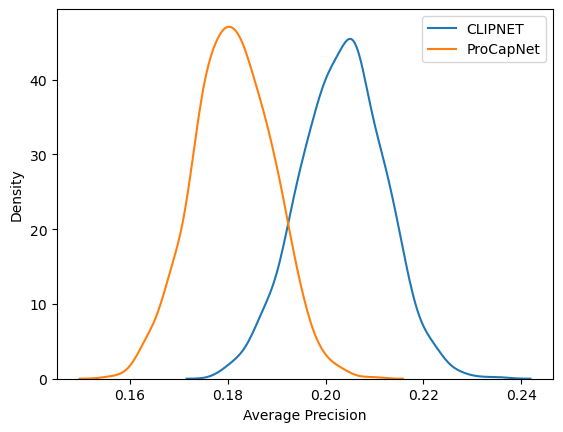

In [19]:
sns.kdeplot(clipnet_map_bootstrap, label="CLIPNET", color=colors[0])
sns.kdeplot(procapnet_map_bootstrap, label="ProCapNet", color=colors[1])
plt.xlabel("Average Precision")
plt.ylabel("Density")
plt.legend()

In [43]:
wilcoxon(procapnet_map_bootstrap, clipnet_map_bootstrap)

WilcoxonResult(statistic=0.0, pvalue=3.325859118934513e-165)

In [42]:
ttest_rel(procapnet_map_bootstrap, clipnet_map_bootstrap)

TtestResult(statistic=-109.30750487839582, pvalue=0.0, df=999)

Text(0.5, 0, 'CLIPNET - ProCapNet Average Precision')

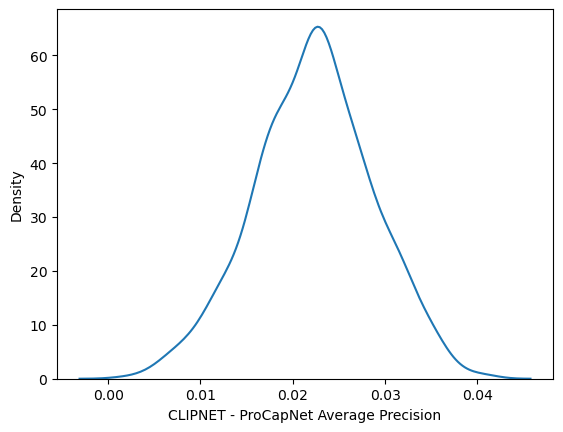

In [22]:
sns.kdeplot(np.array(clipnet_map_bootstrap) - np.array(procapnet_map_bootstrap))
plt.xlabel("CLIPNET - ProCapNet Average Precision")

In [23]:
((np.array(clipnet_map_bootstrap) - np.array(procapnet_map_bootstrap)) <= 0).mean()

0.0

In [36]:
(np.array(clipnet_map_bootstrap) - np.array(procapnet_map_bootstrap)).mean()

0.022224915774805946

In [38]:
(np.array(clipnet_map_bootstrap) - np.array(procapnet_map_bootstrap)).mean()

0.022224915774805946

In [40]:
shapiro(clipnet_map_bootstrap)

ShapiroResult(statistic=0.9988955855369568, pvalue=0.8147349953651428)

In [41]:
shapiro(procapnet_map_bootstrap)

ShapiroResult(statistic=0.9991496801376343, pvalue=0.9385776519775391)